In [1]:
import os
# Set the threading layer before importing torch or numpy.
os.environ["MKL_THREADING_LAYER"] = "GNU"

# Force Matplotlib to use a non-interactive backend.
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm  # Notebook-friendly progress bar
import gc

Diffusion settings

In [2]:
# -----------------------------
# Time Embedding for Diffusion
# -----------------------------
def get_timestep_embedding(timesteps, embedding_dim):
    """
    Generate sinusoidal embeddings for diffusion time steps.
    """
    half_dim = embedding_dim // 2
    emb_factor = np.log(10000) / (half_dim - 1)
    emb_factor = torch.tensor(emb_factor, device=timesteps.device, dtype=torch.float32)
    emb = torch.arange(half_dim, device=timesteps.device, dtype=torch.float32)
    emb = torch.exp(-emb * emb_factor)
    emb = timesteps.float().unsqueeze(1) * emb.unsqueeze(0)
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros(timesteps.size(0), 1, device=timesteps.device)], dim=1)
    return emb

In [3]:
# -----------------------------
# Diffusion Hyperparameters
# -----------------------------
T = 100  # Number of diffusion steps
betas = torch.linspace(1e-4, 0.02, T, dtype=torch.float32)
alphas = 1 - betas
# Set the device (use GPU if available).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
alpha_bars = torch.cumprod(alphas, dim=0).to(device) # noise level schedule

Using device: cuda


Models definition

In [4]:
cond_dim=1
target_dim=1
time_emb_dim=16

In [25]:
class MLP(nn.Module):
    def __init__(self, diffusion=True):
        """
        A simple fully-connected network that takes as input the condition,
        the noisy target, and a time embedding, then predicts the noise to be removed.
        """
        super().__init__()
        self.diffusion = diffusion
        in_channels = cond_dim + target_dim + time_emb_dim if diffusion else cond_dim
        hidden_dim = 64
        self.net = nn.Sequential(
            nn.Linear(in_channels, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.ReLU(),
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, target_dim)
        )
        
    def forward(self, x, y=None, t=None):
        if self.diffusion:
            time_emb = get_timestep_embedding(t, time_emb_dim)
            inp = torch.cat([x, y, time_emb], dim=1)
        else:
            inp = x
        return self.net(inp)

In [26]:
class CNN1D(nn.Module):
    def __init__(self, diffusion=True):
        super().__init__()
        self.diffusion = diffusion
        in_channels = cond_dim + target_dim + time_emb_dim if diffusion else cond_dim
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(64, 64*2, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(64*2, 64, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=1),
            nn.Flatten()
        )

    def forward(self, x, y=None, t=None):
        if self.diffusion:
            time_emb = get_timestep_embedding(t, 16).unsqueeze(-1)
            y = y.unsqueeze(-1)
            x = torch.cat([x.unsqueeze(-1), y, time_emb], dim=1)
        else:
            x = x.unsqueeze(-1)
        return self.net(x)

In [27]:
class TransformerModel(nn.Module):
    def __init__(self, diffusion=True):
        super().__init__()
        self.diffusion = diffusion
        input_dim = cond_dim + target_dim + time_emb_dim if diffusion else cond_dim
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=64, nhead=8),
            num_layers=3
        )
        self.embedding = nn.Linear(input_dim, 64)
        self.fc = nn.Linear(64, 1)

    def forward(self, x, y=None, t=None):
        if self.diffusion:
            time_emb = get_timestep_embedding(t, 16)
            x = torch.cat([x, y, time_emb], dim=1)
        x = self.embedding(x).unsqueeze(0)
        out = self.fc(self.encoder(x).squeeze())
        return out


Diffusion training / inference

In [12]:
# -----------------------------
# Training Setup
# -----------------------------
def train_diffusion(model, dataloader, optimizer, n_epochs=5, device="cpu"):
    mse_loss = nn.MSELoss()
    model.train()
    loss_epoch = []
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            cond_batch, target_batch = batch  # cond_batch is condition, target_batch is target
            cond_batch = cond_batch.to(device)
            target_batch = target_batch.to(device)
            batch_size = cond_batch.size(0)
            
            # Select a random time-step for each sample.
            t = torch.randint(0, T, (batch_size,), device=device)
            alpha_bar_t = alpha_bars[t].unsqueeze(1).to(device)
            epsilon = torch.randn_like(target_batch) # generate random noise
            
            # Forward diffusion: add noise to the target.
            noisy_target = torch.sqrt(alpha_bar_t) * target_batch \
                           + torch.sqrt(1 - alpha_bar_t) * epsilon
            
            # Predict the noise and compute the loss.
            epsilon_pred = model(cond_batch, noisy_target, t)
            loss = mse_loss(epsilon_pred, epsilon)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * batch_size
        
        average_loss = epoch_loss / len(dataloader.dataset)
        loss_epoch.append(average_loss)
        print(f"Epoch {epoch+1} Loss: {average_loss:.6f}")
        
        # Clean up memory if needed.
        if device.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()
    return loss_epoch

In [13]:
# -----------------------------
# Reverse Diffusion (Sampling)
# -----------------------------
@torch.no_grad()
def sample_diffusion(model, cond, device="cpu"):
    """
    Given the condition input, reverse the diffusion process to generate a sample target.
    """
    model.eval()
    batch_size = cond.size(0)
    noisy_target = torch.randn(batch_size, 1, device=device)
    
    # Reverse the diffusion process from timestep T-1 down to 0.
    for t_int in reversed(range(T)):
        t = torch.full((batch_size,), t_int, device=device, dtype=torch.long)
        alpha_bar_t = alpha_bars[t_int].to(device)
        beta_t = betas[t_int].to(device)
        alpha_t = alphas[t_int].to(device)
        
        # Reshape scalars for broadcasting.
        alpha_bar_t = alpha_bar_t.view(1, 1)
        beta_t = beta_t.view(1, 1)
        alpha_t = alpha_t.view(1, 1)
        
        eps_pred = model(cond, noisy_target, t) # predict noise at t
        noise = torch.randn_like(noisy_target) if t_int > 0 else 0.0
        noisy_target = (1 / torch.sqrt(alpha_t)) * (noisy_target - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_pred) \
                       + torch.sqrt(beta_t) * noise
    
    return noisy_target

SGD training / inference

In [14]:
def train_sgd(model, dataloader, optimizer, n_epochs=5, device="cpu"):
    model.train()
    criterion = nn.MSELoss()
    loss_epoch = []
    for epoch in range(n_epochs):
        epoch_loss = 0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()*x.size(0)
        average_loss = epoch_loss / len(dataloader.dataset)
        print(f"Epoch {epoch+1} Loss: {average_loss:.6f}")
        loss_epoch.append(average_loss)
    return loss_epoch

In [15]:
@torch.no_grad()
def test_sgd(model, cond, device='cpu'):
    model.eval()
    pred = model(cond)
    
    return pred

Main: Data preparation, training, sampling, and saving the figure

In [28]:
X_train = np.load('data/X_train.npy')
Y_train = np.load('data/Y_train.npy')
dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
models = [
        ('MLP', MLP(diffusion=False), MLP(diffusion=True)),
        ('CNN1D', CNN1D(diffusion=False), CNN1D(diffusion=True)),
        ('Transformer', TransformerModel(diffusion=False), TransformerModel(diffusion=True))
    ]

loss_epoch = {}

for name, sgd_model, diff_model in models:
    print(f"\n=== Training {name} ===")

    # SGD training
    print("\nTraining SGD version...")
    sgd_model.to(device)
    optimizer = optim.Adam(sgd_model.parameters(), lr=1e-3)
    sgd_loss = train_sgd(sgd_model, dataloader, optimizer, 10, device)
    torch.save(sgd_model.state_dict(), f'models/{name}_sgd.pth')

    # diffusion training
    print("\nTraining Diffusion version...")
    diff_model.to(device)
    optimizer = optim.Adam(diff_model.parameters(), lr=1e-3)
    diff_loss = train_diffusion(diff_model, dataloader, optimizer, 10, device)
    torch.save(diff_model.state_dict(), f'models/{name}_diffusion.pth')

    loss_epoch[name] = (sgd_loss, diff_loss)



=== Training MLP ===

Training SGD version...
Epoch 1 Loss: 0.102362
Epoch 2 Loss: 0.094801
Epoch 3 Loss: 0.094151
Epoch 4 Loss: 0.094270
Epoch 5 Loss: 0.093963
Epoch 6 Loss: 0.093676
Epoch 7 Loss: 0.093581
Epoch 8 Loss: 0.093620
Epoch 9 Loss: 0.093392
Epoch 10 Loss: 0.093692

Training Diffusion version...


Epoch 1/10: 100%|██████████| 469/469 [00:01<00:00, 351.75it/s]


Epoch 1 Loss: 0.425460


Epoch 2/10: 100%|██████████| 469/469 [00:01<00:00, 356.35it/s]


Epoch 2 Loss: 0.350853


...

Epoch 8 Loss: 0.298799


Epoch 9/10: 100%|██████████| 469/469 [00:03<00:00, 117.36it/s]


Epoch 9 Loss: 0.293826


Epoch 10/10: 100%|██████████| 469/469 [00:03<00:00, 117.76it/s]


Epoch 10 Loss: 0.283964


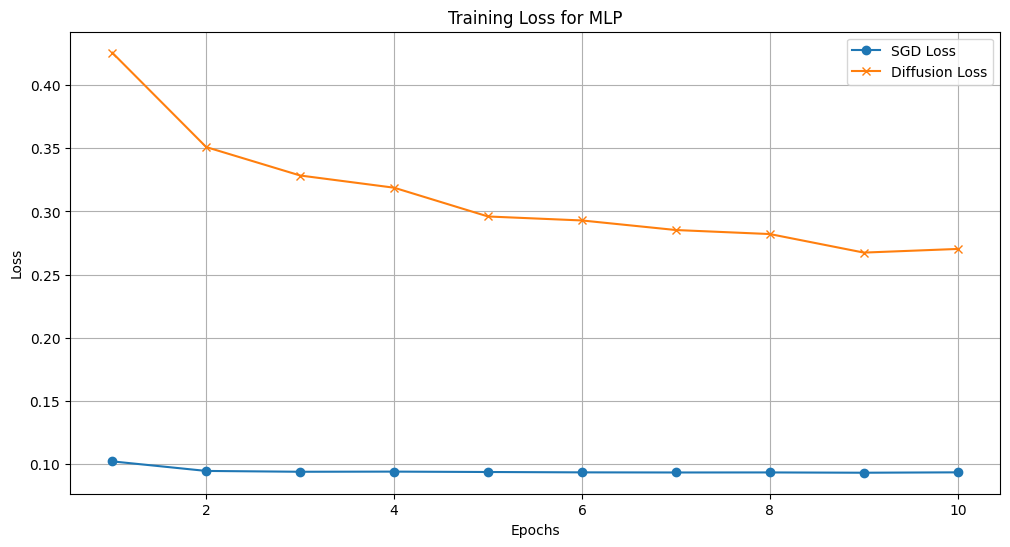

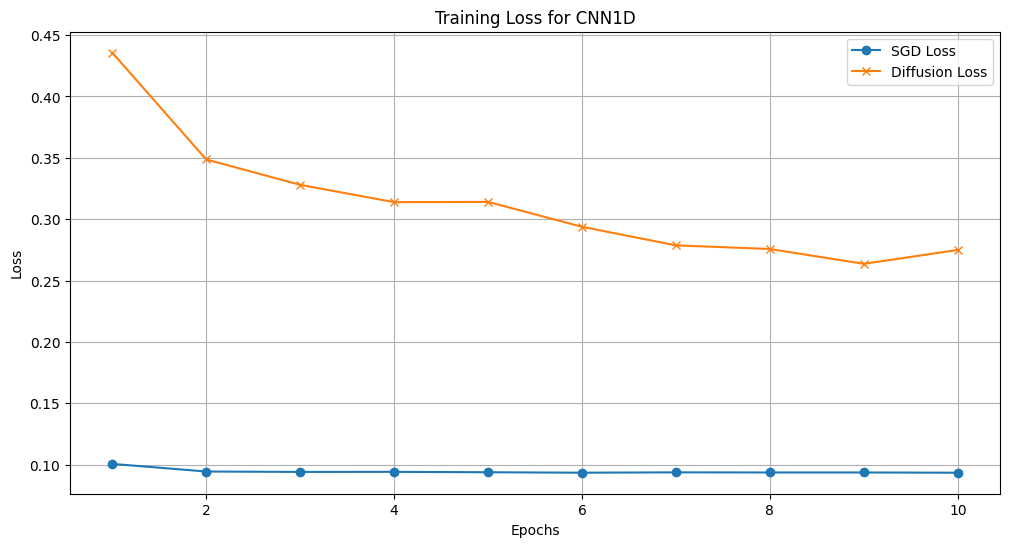

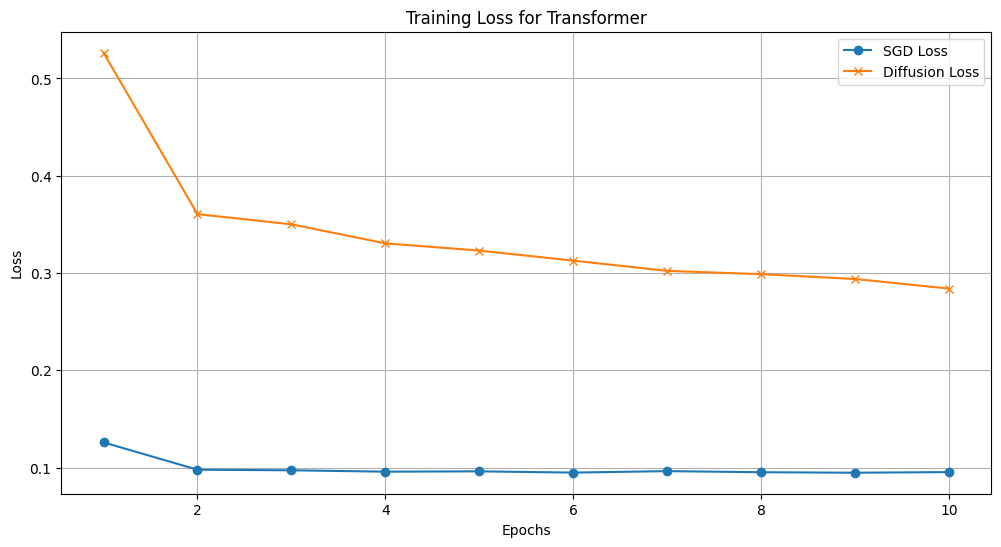

In [29]:
# Plotting Training Performance Graphs

%matplotlib inline
for name, loss in loss_epoch.items():
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, 11), loss[0], label='SGD Loss', marker='o')
    plt.plot(range(1, 11), loss[1], label='Diffusion Loss', marker='x')
    plt.title(f'Training Loss for {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()


=== Testing MLP ===


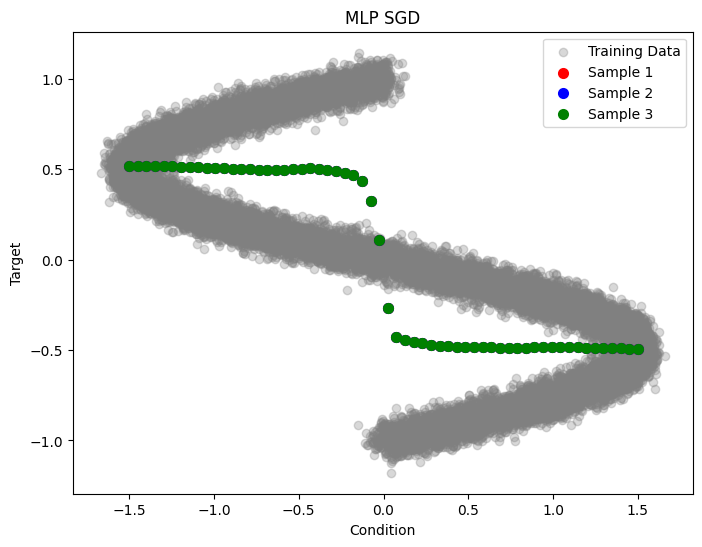

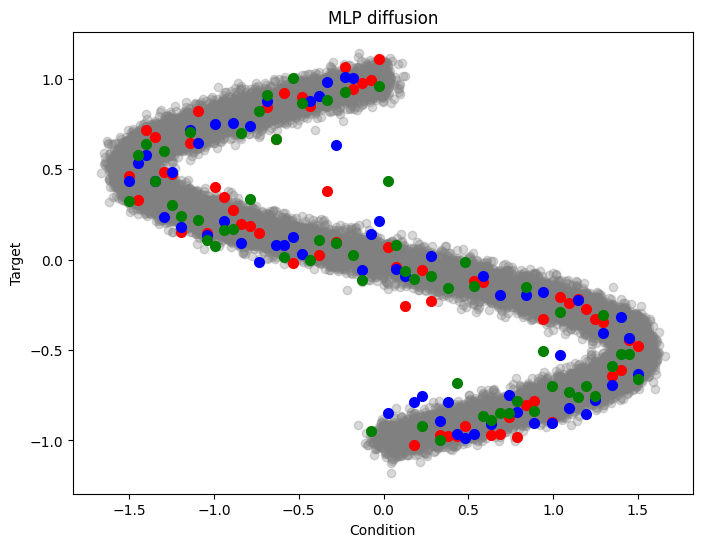


=== Testing CNN1D ===


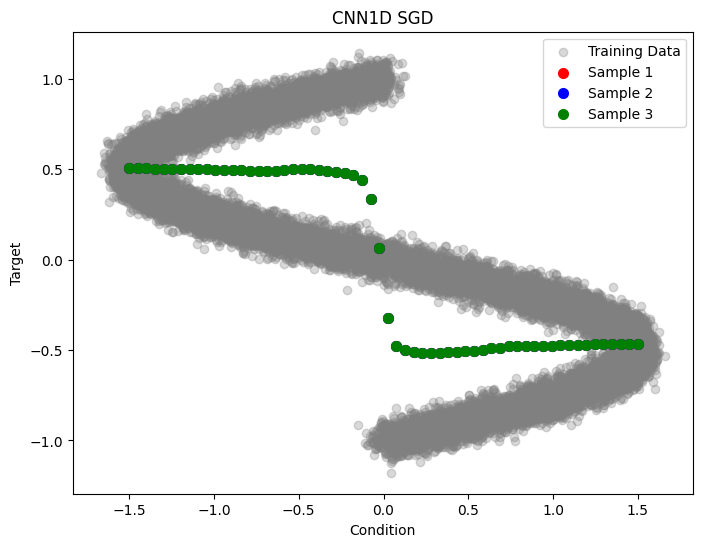

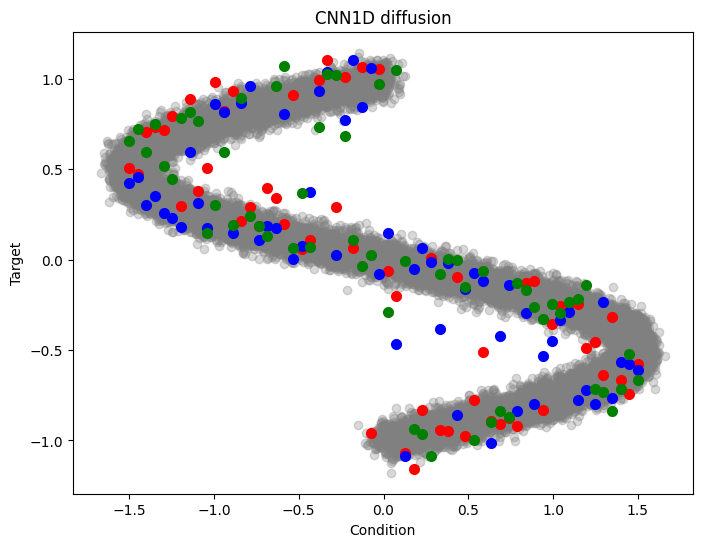


=== Testing Transformer ===


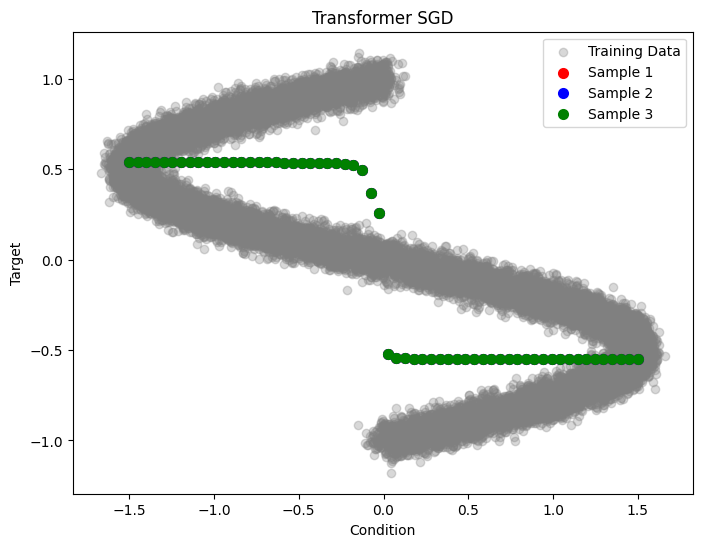

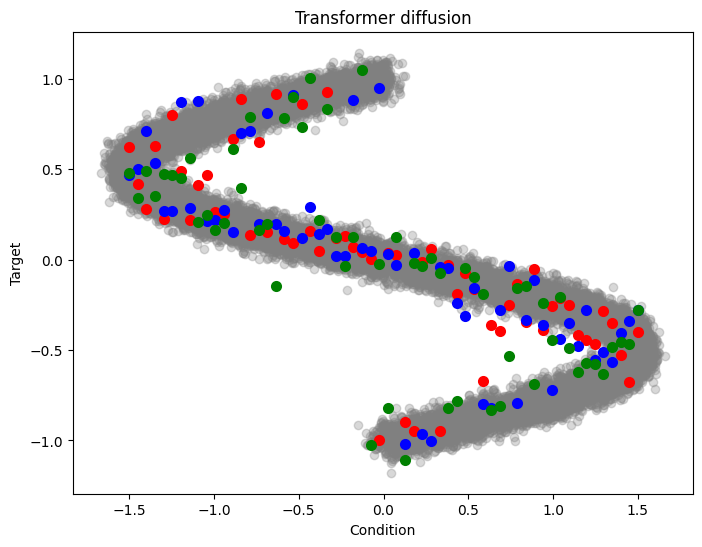

In [30]:
%matplotlib inline
# test
# device = 'cuda:7'

# Sampling: generate samples for a range of condition values.
X_train = np.load('data/X_train.npy')
Y_train = np.load('data/Y_train.npy')
x_test = np.load('data/X_test.npy')
x_test_tensor = torch.from_numpy(x_test).to(device)

# load model
models = [
        ('MLP', MLP(diffusion=False), MLP(diffusion=True)),
        ('CNN1D', CNN1D(diffusion=False), CNN1D(diffusion=True)),
        ('Transformer', TransformerModel(diffusion=False), TransformerModel(diffusion=True))
    ]

n_samples = 3  # Number of sample curves to generate.

for name, sgd_model, diff_model in models:
    print(f"\n=== Testing {name} ===")

    sgd_model = sgd_model.to(device)
    state_dict = torch.load(f'models/{name}_sgd.pth', map_location=device)
    sgd_model.load_state_dict(state_dict)

    all_x = []
    all_y = []
    with torch.no_grad():
        for _ in range(n_samples):
            sample_target = test_sgd(sgd_model, x_test_tensor, device=device)
            all_x.append(x_test)   
            all_y.append(sample_target.cpu().numpy())

    # Visualization: Plot the training (transformed) data and the generated samples.
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train, Y_train, color='gray', alpha=0.3, label='Training Data')
    colors = ['red', 'blue', 'green']
    for i in range(n_samples):
        plt.scatter(all_x[i], all_y[i], color=colors[i], lw=2, label=f'Sample {i+1}')
    plt.xlabel("Condition")
    plt.ylabel("Target")
    plt.title(f"{name} SGD")
    plt.legend()
    plt.show()

    dff_model = diff_model.to(device)
    state_dict = torch.load(f'models/{name}_diffusion.pth', map_location=device)
    diff_model.load_state_dict(state_dict)

    all_x = []
    all_y = []
    with torch.no_grad():
        for _ in range(n_samples):
            sample_target = sample_diffusion(diff_model, x_test_tensor, device=device)
            all_x.append(x_test)   
            all_y.append(sample_target.cpu().numpy())

    # Visualization: Plot the training (transformed) data and the generated samples.
    plt.figure(figsize=(8, 6))
    plt.scatter(X_train, Y_train, color='gray', alpha=0.3, label='Training Data')
    colors = ['red', 'blue', 'green']
    for i in range(n_samples):
        plt.scatter(all_x[i], all_y[i], color=colors[i], lw=2, label=f'Sample {i+1}')
    plt.xlabel("Condition")
    plt.ylabel("Target")
    plt.title(f"{name} diffusion")
    # plt.legend()
    plt.show()

# results_dir = os.path.join(cwd, "results")
# os.makedirs(results_dir, exist_ok=True)
# fig_filename = os.path.join(results_dir, "MLP_diffusion_results_S.png")
# plt.savefig(fig_filename, dpi=100)
# plt.close()  # Free the figure.
# print("Figure successfully saved as:", fig_filename)

# Experimental analysis

Explain model architecture design.

Compare training loss performance.

How to improve preformance could be a bonus, for example, adding more layers.

# Comparison between the two training approaches.

In scenarios where data exhibits a multi-modal distribution (e.g., an S-curve with multiple plausible outputs for a single input), diffusion models demonstrate significant advantages over models trained via Stochastic Gradient Descent (SGD) due to their inherent ability to model uncertainty and capture complex data distributions.

1. SGD’s Limitation: Convergence to Mean

Problem: SGD-driven models (e.g., deterministic neural networks) optimize for a single "best" output by minimizing mean squared error (MSE). For multi-modal data (e.g., an S-curve with multiple valid paths), this forces the model to predict a blurred average of all possible modes, rather than generating diverse, plausible outputs.

2. Diffusion Models’ Strength: Probabilistic Multi-Modal Learning

Mechanism: Diffusion models learn to iteratively denoise data by reversing a gradual noising process. This training paradigm explicitly models the probability density of the data distribution across multiple noise levels, enabling them to:

Preserve uncertainty: By learning transitions between noise-corrupted and clean data, they retain information about all plausible modes (e.g., both branches of an S-curve).

Generate diverse samples: During inference, stochastic denoising steps allow sampling from different modes, producing varied outputs for the same input.

Conclusion

Diffusion models excel in scenarios requiring multi-modal modeling (e.g., S-curves) by leveraging their probabilistic framework to learn and sample from the full data distribution. In contrast, SGD-driven deterministic models collapse to averages, sacrificing diversity and accuracy. This makes diffusion particularly powerful for generative tasks, uncertainty-aware prediction, and handling one-to-many mappings.

(Only for reference, without considering words number)